#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

#### Import Datasets

In [2]:
%store -r Set1_X_Train_scaled
%store -r Set1_X_Test_scaled
%store -r Set1_y_Train
%store -r Set1_y_Test

#### LInear Regression

In [3]:
linear_reg = LinearRegression()

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

linear_reg.fit(Set1_X_Train_scaled, Set1_y_Train_array)

linear_reg_pred_train = linear_reg.predict(Set1_X_Train_scaled)
linear_reg_pred_test = linear_reg.predict(Set1_X_Test_scaled)


#### Linear Regression Evaluation

In [4]:
# Mean Squared Error
mse_train = mean_squared_error(Set1_y_Train_array, linear_reg_pred_train)
mse_test = mean_squared_error(Set1_y_Test_array, linear_reg_pred_test)

# Root Mean Squared Error
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

# Mean Absolute Error
mae_train = mean_absolute_error(Set1_y_Train_array, linear_reg_pred_train)
mae_test = mean_absolute_error(Set1_y_Test_array, linear_reg_pred_test)

# R2 Score
r2_train = r2_score(Set1_y_Train_array, linear_reg_pred_train)
r2_test = r2_score(Set1_y_Test_array, linear_reg_pred_test)

# Coefficient of Determination
cod_train = explained_variance_score(Set1_y_Train_array, linear_reg_pred_train)
cod_test = explained_variance_score(Set1_y_Test_array, linear_reg_pred_test)

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train)
print("Root Mean Squared Error:", rmse_train)
print("Mean Absolute Error:", mae_train)
print("R-squared Score:", r2_train)
print("Coefficient of Determination:", cod_train)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test)
print("Root Mean Squared Error:", rmse_test)
print("Mean Absolute Error:", mae_test)
print("R-squared Score:", r2_test)
print("Coefficient of Determination:", cod_test)

--Training Set Evaluation--
Mean Squared Error: 1994.7662987722956
Root Mean Squared Error: 44.66280666026594
Mean Absolute Error: 34.1002696839551
R-squared Score: 0.5795500450752362
Coefficient of Determination: 0.5795500450752362

--Testing Set Evaluation--
Mean Squared Error: 1940.7186759499316
Root Mean Squared Error: 44.05358868412347
Mean Absolute Error: 34.375170023896445
R-squared Score: -0.12383626184046093
Coefficient of Determination: -0.12020475432312172


#### Plot Evaluation Results

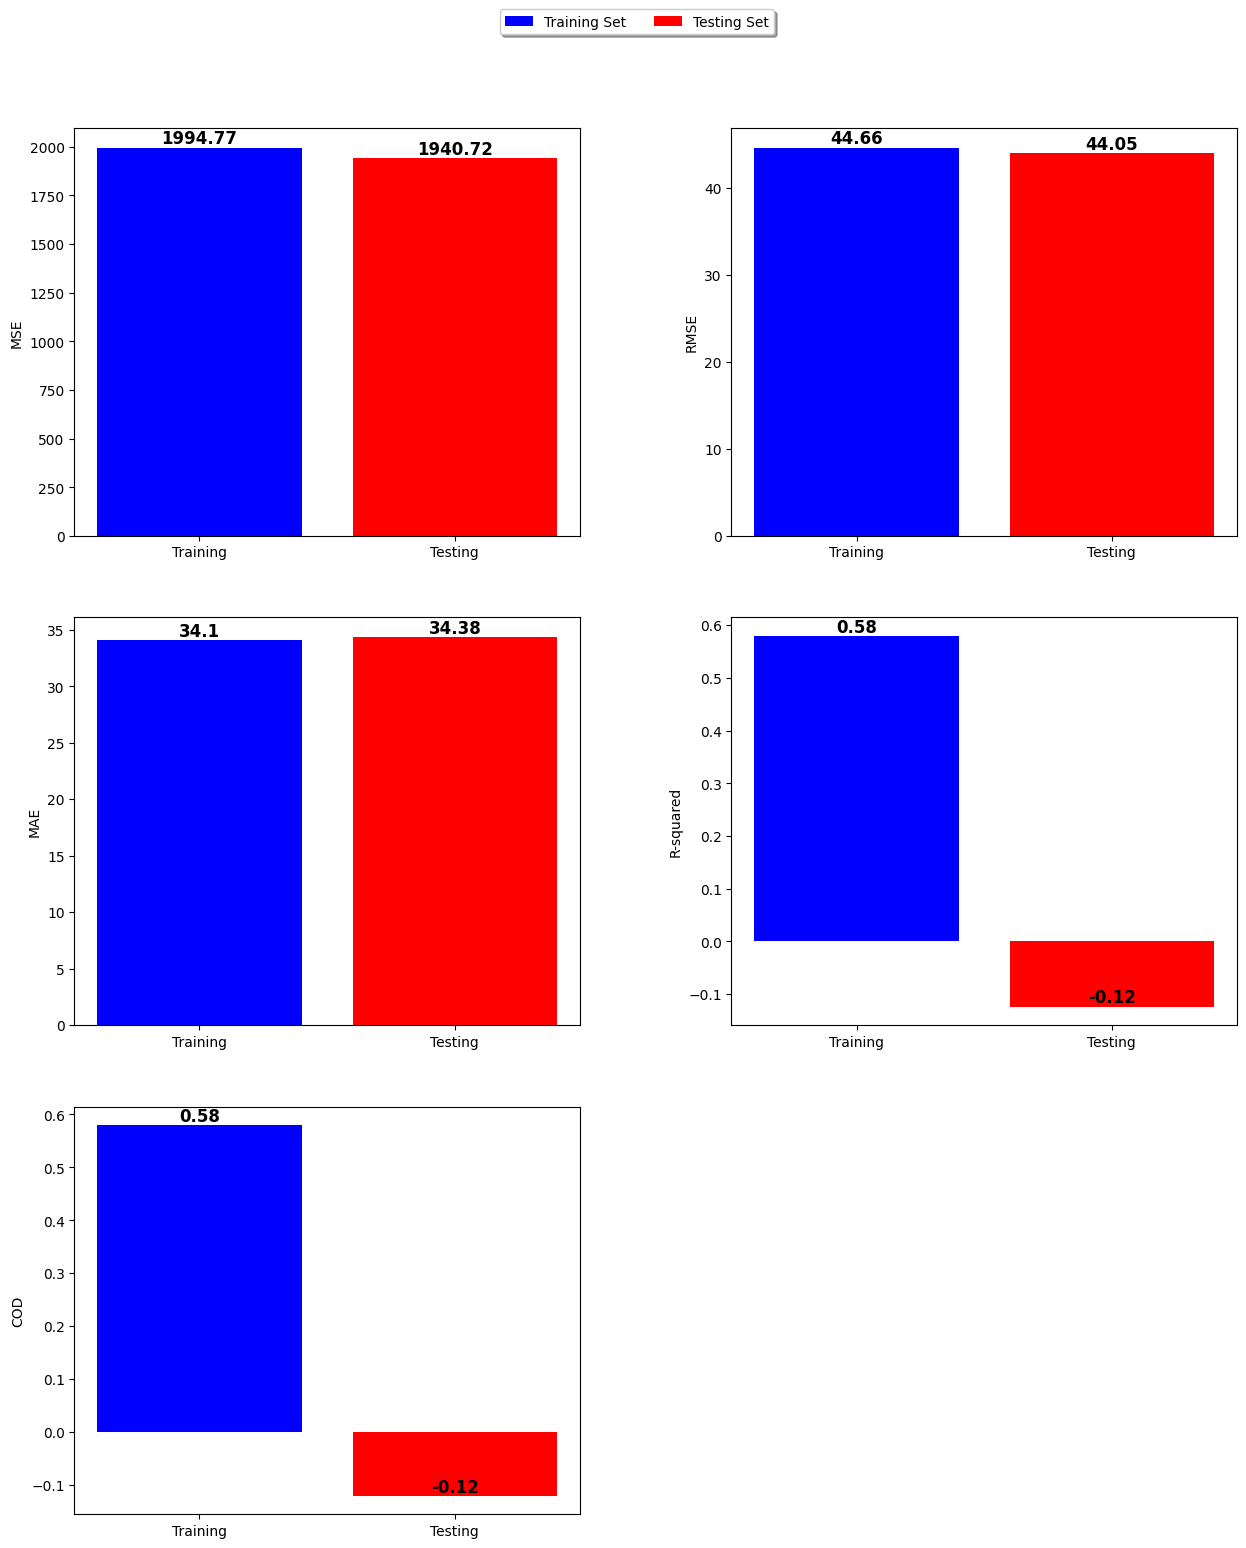

In [5]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train, rmse_train, mae_train, r2_train, cod_train]
test_metrics = [mse_test, rmse_test, mae_test, r2_test, cod_test]

num_metrics = len(metrics)
num_cols = 2
num_rows = (num_metrics + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i // num_cols, i % num_cols]
    ax.bar('Training', train_metric, color='b', label='Training Set')
    ax.bar('Testing', test_metric, color='r', label='Testing Set')
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Position the legend in the middle
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

for i in range(num_metrics, num_rows * num_cols):
    fig.delaxes(axes.flatten()[i])

plt.subplots_adjust(wspace=0.3)
plt.show()